In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv("cleaned_startup_data.csv")   
df.head()

,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,...,category_code_search,category_code_security,category_code_semiconductor,category_code_social,category_code_software,category_code_sports,category_code_transportation,category_code_travel,category_code_web,status
0,1.027268,1.451271,0.738961,0.005448,-0.313102,0.623990,0.679721,-0.648696,0.495665,-0.132140,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,-0.429945,1
1,-0.341900,-0.823630,0.738961,1.151960,2.044918,1.481175,0.782391,0.177541,1.215002,0.077455,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,-0.429945,1
2,-1.501922,-0.610018,0.738961,-0.479349,-0.977162,-0.553767,-0.852690,-0.373284,-0.943010,-0.120401,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,2.325881,1
3,-0.320134,-0.827040,0.738961,0.357050,0.466454,1.113359,0.440795,-0.373284,0.495665,0.076928,...,-0.114771,-0.144975,-0.198531,-0.124103,2.243363,-0.032933,-0.0466,-0.093505,-0.429945,1
4,-0.197397,-0.843535,-1.353251,-0.891013,-0.762888,-1.074277,-1.590895,-0.786402,-0.223673,-0.127260,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,-0.429945,0


In [79]:
print("Rows, Columns:", df.shape)
df.info()

Rows, Columns: (923, 70)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        923 non-null    float64
 1   longitude                       923 non-null    float64
 2   labels                          923 non-null    float64
 3   age_first_funding_year          923 non-null    float64
 4   age_last_funding_year           923 non-null    float64
 5   age_first_milestone_year        923 non-null    float64
 6   age_last_milestone_year         923 non-null    float64
 7   relationships                   923 non-null    float64
 8   funding_rounds                  923 non-null    float64
 9   funding_total_usd               923 non-null    float64
 10  milestones                      923 non-null    float64
 11  is_ca                           923 non-null    float64
 12  is_ny      

In [80]:
df.isnull().sum()

latitude                        0
longitude                       0
labels                          0
age_first_funding_year          0
age_last_funding_year           0
                               ..
category_code_sports            0
category_code_transportation    0
category_code_travel            0
category_code_web               0
status                          0
Length: 70, dtype: int64

In [81]:
df.duplicated().sum()

0

In [82]:
df["status"].value_counts()

status
1    597
0    326
Name: count, dtype: int64

In [83]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.head()

,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,...,category_code_search,category_code_security,category_code_semiconductor,category_code_social,category_code_software,category_code_sports,category_code_transportation,category_code_travel,category_code_web,status
0,1.027268,1.451271,0.738961,0.005448,-0.313102,0.623990,0.679721,-0.648696,0.495665,-0.132140,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,-0.429945,1
1,-0.341900,-0.823630,0.738961,1.151960,2.044918,1.481175,0.782391,0.177541,1.215002,0.077455,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,-0.429945,1
2,-1.501922,-0.610018,0.738961,-0.479349,-0.977162,-0.553767,-0.852690,-0.373284,-0.943010,-0.120401,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,2.325881,1
3,-0.320134,-0.827040,0.738961,0.357050,0.466454,1.113359,0.440795,-0.373284,0.495665,0.076928,...,-0.114771,-0.144975,-0.198531,-0.124103,2.243363,-0.032933,-0.0466,-0.093505,-0.429945,1
4,-0.197397,-0.843535,-1.353251,-0.891013,-0.762888,-1.074277,-1.590895,-0.786402,-0.223673,-0.127260,...,-0.114771,-0.144975,-0.198531,-0.124103,-0.445759,-0.032933,-0.0466,-0.093505,-0.429945,0


In [84]:
stats_table = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Standard Deviation": numeric_df.std(),
    "Maximum": numeric_df.max(),
    "Minimum": numeric_df.min()
})
stats_table

,Mean,Median,Standard Deviation,Maximum,Minimum
latitude,-2.752102e-16,-0.197397,1.000542,5.567043,-3.413608
longitude,4.811367e-17,-0.662801,1.000542,5.432766,-0.858624
labels,-5.196277e-17,0.738961,1.000542,0.738961,-1.353251
age_first_funding_year,9.622735e-18,-0.314469,1.000542,7.835623,-4.496546
age_last_funding_year,9.622735e-18,-0.135743,1.000542,6.056176,-4.375164
...,...,...,...,...,...
category_code_sports,1.347183e-17,-0.032933,1.000542,30.364453,-0.032933
category_code_transportation,6.351005e-17,-0.046600,1.000542,21.459264,-0.046600
category_code_travel,8.468007e-17,-0.093505,1.000542,10.694625,-0.093505
category_code_web,4.618913e-17,-0.429945,1.000542,2.325881,-0.429945


In [85]:
stats_table.to_csv("stat_analysis.csv")

In [86]:
correlation_with_target = df.corr(numeric_only=True)["status"].sort_values(ascending=False)

correlation_table = pd.DataFrame({
    "Feature": correlation_with_target.index,
    "Correlation with status": correlation_with_target.values
})

correlation_table = correlation_table[
    ~correlation_table["Feature"].isin(["status", "labels"])
]

correlation_table

,Feature,Correlation with status
2,relationships,0.360434
3,milestones,0.328260
4,is_top500,0.310652
5,age_last_milestone_year,0.240755
6,has_roundb,0.208257
...,...,...
65,age_first_funding_year,-0.075637
66,category_code_public_relations,-0.086157
67,category_code_hardware,-0.086946
68,category_code_other,-0.106843


In [87]:
correlation_table.to_csv("corr_with_status.csv", index=False)

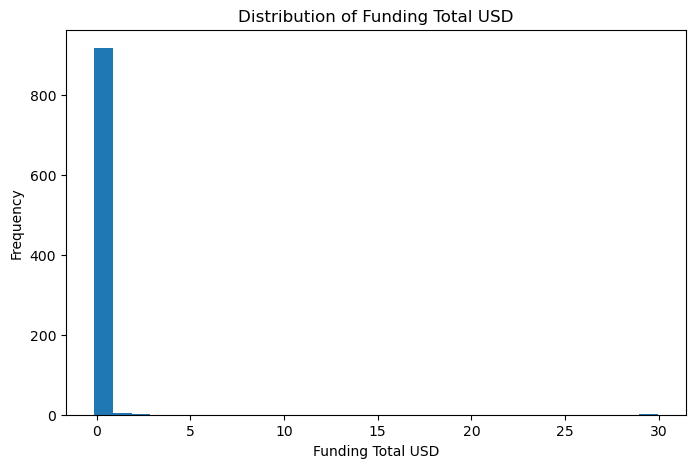

In [88]:
plt.figure(figsize=(8, 5))
plt.hist(df["funding_total_usd"], bins=30)
plt.title("Distribution of Funding Total USD")
plt.xlabel("Funding Total USD")
plt.ylabel("Frequency")
plt.show()

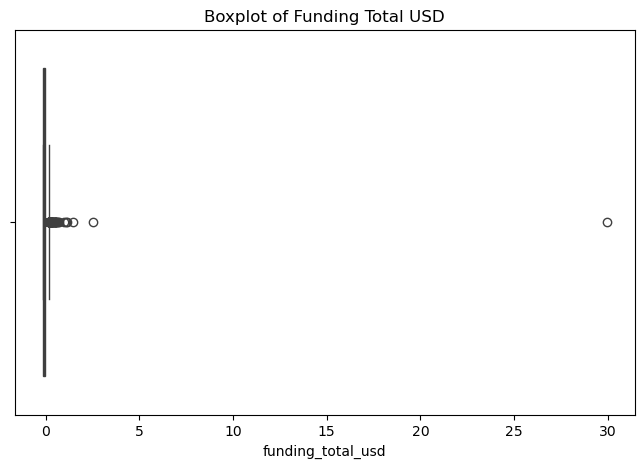

In [89]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["funding_total_usd"])
plt.title("Boxplot of Funding Total USD")
plt.show()

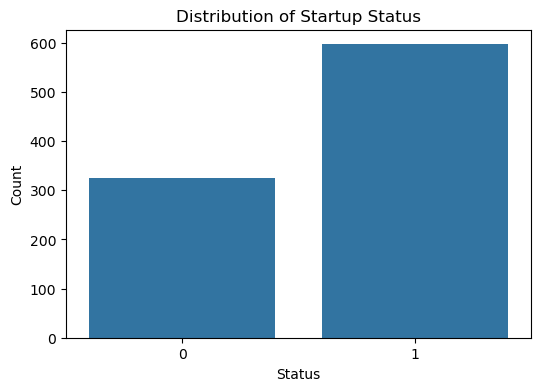

In [90]:
plt.figure(figsize=(6, 4))
sns.countplot(x="status", data=df)
plt.title("Distribution of Startup Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

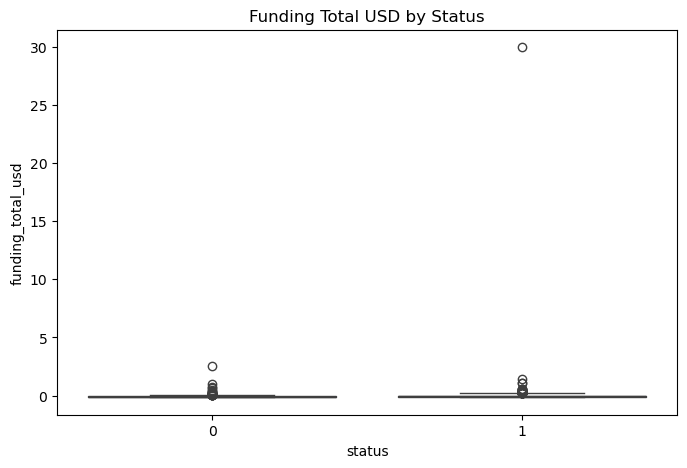

In [91]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="status", y="funding_total_usd", data=df)
plt.title("Funding Total USD by Status")
plt.show()

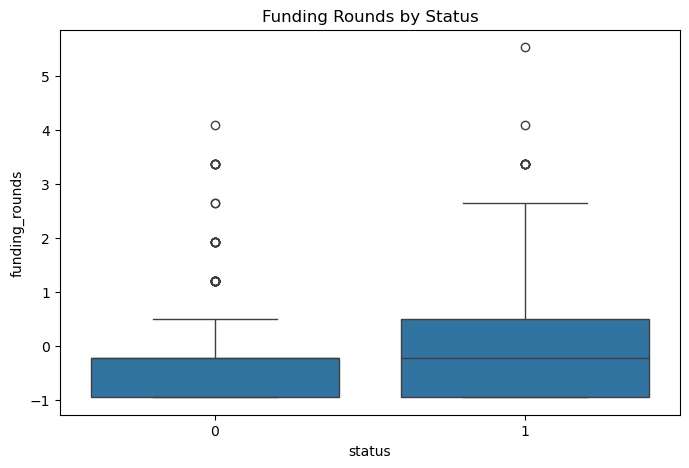

In [92]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="status", y="funding_rounds", data=df)
plt.title("Funding Rounds by Status")
plt.show()

In [95]:
top_corr = correlation_table.sort_values(
    by="Correlation with status", ascending=False
).head(10).reset_index(drop=True)

top_corr

,Feature,Correlation with status
0,relationships,0.360434
1,milestones,0.328260
2,is_top500,0.310652
3,age_last_milestone_year,0.240755
4,has_roundb,0.208257
5,funding_rounds,0.206049
6,avg_participants,0.185992
7,has_rounda,0.184307
8,has_roundc,0.165902
9,age_first_milestone_year,0.162766


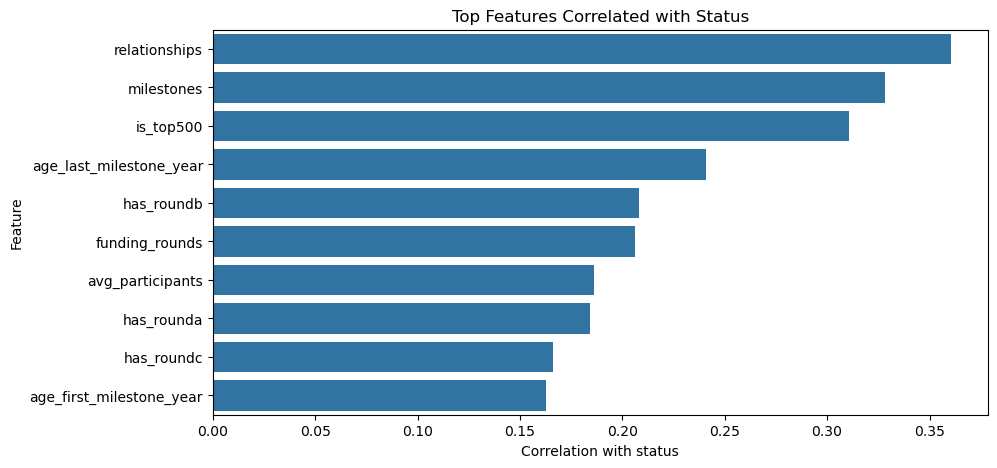

In [94]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x="Correlation with status",
    y="Feature",
    data=top_corr
)
plt.title("Top Features Correlated with Status")
plt.show()